# Step 4: Model Implementation

This notebook performs formal model implementation for the eCommerce future-purchase prediction problem.

The scope of this step includes:

1. Loading the leakage-safe model-ready dataset  
2. Recreating the chronological train-validation-test split  
3. Training baseline supervised models  
4. Comparing models using relevant classification metrics  
5. Tuning the best-performing model  
6. Evaluating the selected model once on the untouched test set  
7. Saving trained model artifacts, metrics, predictions, and configuration files  

The target variable is `future_purchase`, which indicates whether a customer session resulted in a purchase after the first two observed events.

# Import Libraries and Configure Project Paths

In [21]:
from pathlib import Path
import inspect
import json
import platform
import sys
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import display

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# Locate project root whether notebook is run from project_folder/
# or from project_folder/notebooks/
current_folder = Path.cwd().resolve()

possible_project_roots = [
    current_folder,
    current_folder.parent
]

PROJECT_ROOT = next(
    (
        folder
        for folder in possible_project_roots
        if (folder / "data" / "processed").exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate project root. Expected folder was not found:\n"
        "data/processed\n\n"
        "Please confirm that this notebook is inside project_folder/notebooks/"
        " or project_folder/."
    )

PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"
MODELS_FOLDER = PROJECT_ROOT / "models"
REPORTS_FOLDER = PROJECT_ROOT / "reports"

MODELS_FOLDER.mkdir(parents=True, exist_ok=True)
REPORTS_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_READY_DATA_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_modeling_dataset_ready_for_split.csv"
)

FEATURE_INVENTORY_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_feature_inventory_with_selection_status.csv"
)

if not MODEL_READY_DATA_PATH.exists():
    raise FileNotFoundError(
        "Model-ready dataset was not found:\n"
        f"{MODEL_READY_DATA_PATH}\n\n"
        "Model ready data path not found."
    )

if not FEATURE_INVENTORY_PATH.exists():
    raise FileNotFoundError(
        "Feature inventory with selection status was not found:\n"
        f"{FEATURE_INVENTORY_PATH}\n\n"
        "Feature inventory path not found."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Model-ready dataset: {MODEL_READY_DATA_PATH}")
print(f"Feature inventory: {FEATURE_INVENTORY_PATH}")
print(f"Models folder: {MODELS_FOLDER}")
print(f"Reports folder: {REPORTS_FOLDER}")
print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Operating system: {platform.system()} {platform.release()}")

Project root: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder
Model-ready dataset: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_modeling_dataset_ready_for_split.csv
Feature inventory: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_feature_inventory_with_selection_status.csv
Models folder: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\models
Reports folder: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\reports
Python version: 3.14.5
pandas version: 3.0.3
scikit-learn version: 1.9.0
Operating system: Windows 11


# Load Model-Ready Dataset and Recreate Chronological Split

In [23]:
# Load model-ready dataset.
model_ready_data = pd.read_csv(MODEL_READY_DATA_PATH)

# Load feature inventory.
feature_inventory = pd.read_csv(FEATURE_INVENTORY_PATH)

TARGET_COLUMN = "future_purchase"
TIME_COLUMN = "first_event_time"
SESSION_COLUMN = "user_session"

# Retained features from L1 feature selection.
retained_feature_inventory = feature_inventory.loc[
    feature_inventory["selected_by_l1_feature_selection"].eq(True)
].copy()

retained_raw_features = retained_feature_inventory["feature"].tolist()

numeric_features = retained_feature_inventory.loc[
    retained_feature_inventory["feature_type"].eq("Numeric"),
    "feature"
].tolist()

categorical_features = retained_feature_inventory.loc[
    retained_feature_inventory["feature_type"].eq("Categorical"),
    "feature"
].tolist()

required_columns = (
    [SESSION_COLUMN, TIME_COLUMN, TARGET_COLUMN]
    + retained_raw_features
)

missing_columns = [
    column
    for column in required_columns
    if column not in model_ready_data.columns
]

if missing_columns:
    raise KeyError(
        "The model-ready dataset is missing required columns:\n"
        + "\n".join(missing_columns)
    )

# Restore data types.
model_ready_data[TIME_COLUMN] = pd.to_datetime(
    model_ready_data[TIME_COLUMN],
    errors="coerce",
    utc=True
)

model_ready_data[TARGET_COLUMN] = pd.to_numeric(
    model_ready_data[TARGET_COLUMN],
    errors="coerce"
).astype("int8")

for feature in numeric_features:
    model_ready_data[feature] = pd.to_numeric(
        model_ready_data[feature],
        errors="coerce"
    )

for feature in categorical_features:
    model_ready_data[feature] = (
        model_ready_data[feature]
        .astype("string")
        .fillna("unknown")
    )

# Validate dataset.
if model_ready_data[SESSION_COLUMN].duplicated().any():
    raise ValueError("Duplicate user_session values were found.")

if model_ready_data[TIME_COLUMN].isna().any():
    raise ValueError("Invalid first_event_time values were found.")

if model_ready_data[TARGET_COLUMN].isna().any():
    raise ValueError("Missing future_purchase labels were found.")

# Sort chronologically by prediction time.
split_source = (
    model_ready_data
    .sort_values(
        by=[TIME_COLUMN, SESSION_COLUMN],
        kind="stable"
    )
    .reset_index(drop=True)
)

total_sessions = len(split_source)

train_cut_index = int(total_sessions * 0.70)
validation_cut_index = int(total_sessions * 0.85)

train_end_time = split_source.iloc[train_cut_index - 1][TIME_COLUMN]
validation_end_time = split_source.iloc[
    validation_cut_index - 1
][TIME_COLUMN]

train_data = split_source.loc[
    split_source[TIME_COLUMN].le(train_end_time)
].copy()

validation_data = split_source.loc[
    split_source[TIME_COLUMN].gt(train_end_time)
    & split_source[TIME_COLUMN].le(validation_end_time)
].copy()

test_data = split_source.loc[
    split_source[TIME_COLUMN].gt(validation_end_time)
].copy()

X_train = train_data[retained_raw_features].copy()
y_train = train_data[TARGET_COLUMN].copy()

X_validation = validation_data[retained_raw_features].copy()
y_validation = validation_data[TARGET_COLUMN].copy()

X_test = test_data[retained_raw_features].copy()
y_test = test_data[TARGET_COLUMN].copy()

def summarize_split(split_name, dataframe):
    return {
        "split": split_name,
        "sessions": len(dataframe),
        "percentage_of_all_sessions": round(
            len(dataframe) / total_sessions * 100,
            2
        ),
        "future_purchase_sessions": int(
            dataframe[TARGET_COLUMN].sum()
        ),
        "future_purchase_rate_percent": round(
            dataframe[TARGET_COLUMN].mean() * 100,
            2
        ),
        "first_prediction_time": dataframe[TIME_COLUMN].min(),
        "last_prediction_time": dataframe[TIME_COLUMN].max()
    }

split_summary = pd.DataFrame([
    summarize_split("Training", train_data),
    summarize_split("Validation", validation_data),
    summarize_split("Test", test_data)
])

feature_summary = pd.DataFrame({
    "metric": [
        "Total model-ready sessions",
        "Target column",
        "Retained raw features",
        "Numeric features",
        "Categorical features",
        "Training sessions",
        "Validation sessions",
        "Test sessions"
    ],
    "value": [
        f"{total_sessions:,}",
        TARGET_COLUMN,
        len(retained_raw_features),
        len(numeric_features),
        len(categorical_features),
        f"{len(train_data):,}",
        f"{len(validation_data):,}",
        f"{len(test_data):,}"
    ]
})

print("Step 4 Dataset and Feature Summary")
display(feature_summary)

print("Chronological Train-Validation-Test Split")
display(split_summary)

print("Retained Features")
display(pd.DataFrame({
    "feature": retained_raw_features,
    "feature_type": [
        "Numeric" if feature in numeric_features else "Categorical"
        for feature in retained_raw_features
    ]
}))

assert train_data[TIME_COLUMN].max() < validation_data[TIME_COLUMN].min()
assert validation_data[TIME_COLUMN].max() < test_data[TIME_COLUMN].min()

assert set(train_data[SESSION_COLUMN]).isdisjoint(
    set(validation_data[SESSION_COLUMN])
)

assert set(train_data[SESSION_COLUMN]).isdisjoint(
    set(test_data[SESSION_COLUMN])
)

assert set(validation_data[SESSION_COLUMN]).isdisjoint(
    set(test_data[SESSION_COLUMN])
)

print("Chronological split recreation and validation checks passed.")

Step 4 Dataset and Feature Summary


,metric,value
0,Total model-ready sessions,"92,799"
1,Target column,future_purchase
2,Retained raw features,16
3,Numeric features,8
4,Categorical features,8
5,Training sessions,"64,959"
6,Validation sessions,"13,920"
7,Test sessions,"13,920"


Chronological Train-Validation-Test Split


,split,sessions,percentage_of_all_sessions,future_purchase_sessions,future_purchase_rate_percent,first_prediction_time,last_prediction_time
0,Training,64959,70.0,7974,12.28,2020-04-01 00:00:53+00:00,2020-04-23 10:45:02+00:00
1,Validation,13920,15.0,1834,13.18,2020-04-23 10:45:05+00:00,2020-04-27 06:58:38+00:00
2,Test,13920,15.0,1867,13.41,2020-04-27 06:58:53+00:00,2020-04-30 23:58:40+00:00


Retained Features


,feature,feature_type
0,early_cart_count,Numeric
1,early_unique_products,Numeric
2,early_unique_categories,Numeric
3,early_unique_brands,Numeric
4,early_zero_price_event_count,Numeric
5,price_for_aggregation_first,Numeric
6,price_for_aggregation_second,Numeric
7,early_event_gap_log1p,Numeric
8,event_type_second,Categorical
9,category_code_clean_first,Categorical


Chronological split recreation and validation checks passed.


# Shared Preprocessing and Evaluation Functions

In [3]:
def create_preprocessor(scale_numeric=True):
    """
    Create a preprocessing pipeline for numeric and categorical features.

    The preprocessor is fitted only on the training data when used inside
    a model pipeline, preventing validation/test leakage.
    """
    one_hot_parameters = {
        "handle_unknown": "infrequent_if_exist",
        "min_frequency": 50
    }

    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        one_hot_parameters["sparse_output"] = True
    else:
        one_hot_parameters["sparse"] = True

    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler(with_mean=False))
        )

    numeric_pipeline = Pipeline(steps=numeric_steps)

    categorical_pipeline = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="unknown"
            )
        ),
        (
            "encoder",
            OneHotEncoder(**one_hot_parameters)
        )
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features)
        ],
        remainder="drop",
        sparse_threshold=0.3
    )


def evaluate_model(
    model_name,
    fitted_pipeline,
    X_data,
    y_data,
    threshold=0.50,
    training_time_seconds=None
):
    """
    Evaluate a fitted binary-classification pipeline using predicted probabilities.
    """
    probabilities = fitted_pipeline.predict_proba(X_data)[:, 1]
    predictions = (probabilities >= threshold).astype("int8")

    return {
        "model": model_name,
        "threshold": threshold,
        "pr_auc": average_precision_score(y_data, probabilities),
        "roc_auc": roc_auc_score(y_data, probabilities),
        "accuracy": accuracy_score(y_data, predictions),
        "precision": precision_score(y_data, predictions, zero_division=0),
        "recall": recall_score(y_data, predictions, zero_division=0),
        "f1_score": f1_score(y_data, predictions, zero_division=0),
        "sessions_targeted": int(predictions.sum()),
        "percentage_targeted": predictions.mean() * 100,
        "training_time_seconds": training_time_seconds,
        "probabilities": probabilities,
        "predictions": predictions
    }


def create_scalar_result_table(result_dictionary):
    """
    Convert a model-result dictionary into a display-ready one-row DataFrame.
    Probability and prediction arrays are excluded.
    """
    excluded_keys = {"probabilities", "predictions"}

    return pd.DataFrame([{
        key: value
        for key, value in result_dictionary.items()
        if key not in excluded_keys
    }])


print("Shared preprocessing and evaluation functions are ready.")

Shared preprocessing and evaluation functions are ready.


# Train and Evaluate Logistic Regression Baseline

In [4]:
from sklearn.linear_model import LogisticRegression

logistic_regression_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=True)
    ),
    (
        "model",
        LogisticRegression(
            solver="lbfgs",
            class_weight="balanced",
            C=1.0,
            max_iter=4000,
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

logistic_regression_pipeline.fit(
    X_train,
    y_train
)

logistic_training_time_seconds = time.perf_counter() - start_time

logistic_validation_result = evaluate_model(
    model_name="Logistic Regression",
    fitted_pipeline=logistic_regression_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=logistic_training_time_seconds
)

print("Logistic Regression Validation Metrics")
display(create_scalar_result_table(logistic_validation_result))

Logistic Regression Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Logistic Regression,0.5,0.44844,0.776273,0.810776,0.366221,0.597056,0.45398,2990,21.479885,0.912319


## Decision Tree Baseline

A Decision Tree classifier is trained as a non-linear baseline model. Unlike Logistic Regression, a Decision Tree can capture threshold-based rules and interactions among features such as early cart count, event timing, price, category, and brand.

The model is constrained using maximum depth and minimum sample settings to reduce overfitting.

# Train and Evaluate Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        DecisionTreeClassifier(
            criterion="gini",
            max_depth=10,
            min_samples_split=100,
            min_samples_leaf=30,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

decision_tree_pipeline.fit(
    X_train,
    y_train
)

decision_tree_training_time_seconds = time.perf_counter() - start_time

decision_tree_validation_result = evaluate_model(
    model_name="Decision Tree",
    fitted_pipeline=decision_tree_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=decision_tree_training_time_seconds
)

print("Decision Tree Validation Metrics")
display(create_scalar_result_table(decision_tree_validation_result))

Decision Tree Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Decision Tree,0.5,0.451696,0.759656,0.812931,0.367607,0.582879,0.450865,2908,20.890805,0.690766


## Random Forest Model

A Random Forest classifier is trained as an ensemble model. It combines multiple decision trees to improve stability and capture non-linear relationships among early cart activity, event timing, price, product category, brand, and temporal features.

The same chronological training and validation split is used to ensure a fair comparison with Logistic Regression and Decision Tree.

# Train and Evaluate Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=250,
            max_depth=18,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

random_forest_pipeline.fit(
    X_train,
    y_train
)

random_forest_training_time_seconds = time.perf_counter() - start_time

random_forest_validation_result = evaluate_model(
    model_name="Random Forest",
    fitted_pipeline=random_forest_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=random_forest_training_time_seconds
)

print("Random Forest Validation Metrics")
display(create_scalar_result_table(random_forest_validation_result))

Random Forest Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Random Forest,0.5,0.472973,0.781542,0.870618,0.508914,0.513631,0.511262,1851,13.297414,1.537894


# Train and Evaluate XGBoost

In [7]:
# Cell 8: Train and Evaluate XGBoost

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

if not xgboost_available:
    raise ImportError(
        "XGBoost is not installed in this Python environment.\n\n"
        "Install it first by running this in a notebook cell or terminal:\n"
        "pip install xgboost\n\n"
        "After installation, restart the Jupyter kernel and rerun Step 4."
    )

# Scale positive class weight because future_purchase is the minority class.
negative_class_count = int((y_train == 0).sum())
positive_class_count = int((y_train == 1).sum())

xgb_scale_pos_weight = negative_class_count / positive_class_count

xgboost_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=5,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=xgb_scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

start_time = time.perf_counter()

xgboost_pipeline.fit(
    X_train,
    y_train
)

xgboost_training_time_seconds = time.perf_counter() - start_time

xgboost_validation_result = evaluate_model(
    model_name="XGBoost",
    fitted_pipeline=xgboost_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=xgboost_training_time_seconds
)

print("XGBoost Validation Metrics")
display(create_scalar_result_table(xgboost_validation_result))

XGBoost Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,XGBoost,0.5,0.481683,0.787845,0.841379,0.422918,0.559433,0.48169,2426,17.428161,0.81002


## Extra Trees Classifier

An Extra Trees Classifier is trained as another tree-based ensemble model. It is similar to Random Forest, but it introduces more randomness when choosing split thresholds. This can sometimes improve generalization and reduce variance.

Extra Trees is included to compare Random Forest against a more randomized ensemble method.

# Train and Evaluate Extra Trees Classifier

In [8]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        ExtraTreesClassifier(
            n_estimators=300,
            max_depth=18,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

extra_trees_pipeline.fit(
    X_train,
    y_train
)

extra_trees_training_time_seconds = time.perf_counter() - start_time

extra_trees_validation_result = evaluate_model(
    model_name="Extra Trees",
    fitted_pipeline=extra_trees_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=extra_trees_training_time_seconds
)

print("Extra Trees Validation Metrics")
display(create_scalar_result_table(extra_trees_validation_result))

Extra Trees Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Extra Trees,0.5,0.449447,0.769567,0.864799,0.487817,0.523991,0.505258,1970,14.152299,1.559074


## LightGBM Model

LightGBM is trained as a gradient boosting model designed for efficient learning on structured tabular data. Like XGBoost, it builds trees sequentially, where each new tree attempts to correct errors made by previous trees.

LightGBM is included as an additional boosting model to compare against XGBoost and the tree-based ensemble models.

# Train and Evaluate LightGBM

In [12]:
# Cell 10: Train and Evaluate LightGBM

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
except ImportError:
    lightgbm_available = False

if not lightgbm_available:
    raise ImportError(
        "LightGBM is not installed in this Python environment.\n\n"
        "Install it first by running this in a notebook cell or terminal:\n"
        "pip install lightgbm\n\n"
        "After installation, restart the Jupyter kernel and rerun Step 4."
    )

lightgbm_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            class_weight="balanced",
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

start_time = time.perf_counter()

lightgbm_pipeline.fit(
    X_train,
    y_train
)

lightgbm_training_time_seconds = time.perf_counter() - start_time

lightgbm_validation_result = evaluate_model(
    model_name="LightGBM",
    fitted_pipeline=lightgbm_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=lightgbm_training_time_seconds
)

print("LightGBM Validation Metrics")
display(create_scalar_result_table(lightgbm_validation_result))

LightGBM Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,LightGBM,0.5,0.487713,0.78788,0.828879,0.397914,0.582334,0.472776,2684,19.281609,0.639636


# Initial Validation Model Comparison

In [13]:
def extract_scalar_metrics(result_dictionary):
    """Keep only scalar evaluation values for comparison tables."""
    excluded_keys = {"probabilities", "predictions"}

    return {
        key: value
        for key, value in result_dictionary.items()
        if key not in excluded_keys
    }


initial_validation_model_comparison = pd.DataFrame([
    extract_scalar_metrics(logistic_validation_result),
    extract_scalar_metrics(decision_tree_validation_result),
    extract_scalar_metrics(random_forest_validation_result),
    extract_scalar_metrics(extra_trees_validation_result),
    extract_scalar_metrics(xgboost_validation_result),
    extract_scalar_metrics(lightgbm_validation_result)
])

initial_validation_model_comparison = (
    initial_validation_model_comparison
    .sort_values(
        by=["pr_auc", "roc_auc", "f1_score"],
        ascending=False
    )
    .reset_index(drop=True)
)

initial_validation_model_comparison["pr_auc_rank"] = (
    initial_validation_model_comparison["pr_auc"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

initial_validation_model_comparison["selection_status"] = "Comparison model"

initial_validation_model_comparison.loc[
    initial_validation_model_comparison.index == 0,
    "selection_status"
] = "Provisional tuning candidate"

print("Initial Validation Model Comparison")
display(initial_validation_model_comparison)

INITIAL_VALIDATION_COMPARISON_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_initial_validation_model_comparison.csv"
)

initial_validation_model_comparison.to_csv(
    INITIAL_VALIDATION_COMPARISON_PATH,
    index=False
)

provisional_best_model = initial_validation_model_comparison.iloc[0]

print(
    "Provisional best model based on validation PR-AUC: "
    f"{provisional_best_model['model']}"
)

print("Saved initial validation comparison:")
print(INITIAL_VALIDATION_COMPARISON_PATH)

Initial Validation Model Comparison


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds,pr_auc_rank,selection_status
0,LightGBM,0.5,0.487713,0.787880,0.828879,0.397914,0.582334,0.472776,2684,19.281609,0.639636,1,Provisional tuning candidate
1,XGBoost,0.5,0.481683,0.787845,0.841379,0.422918,0.559433,0.481690,2426,17.428161,0.810020,2,Comparison model
2,Random Forest,0.5,0.472973,0.781542,0.870618,0.508914,0.513631,0.511262,1851,13.297414,1.537894,3,Comparison model
3,Decision Tree,0.5,0.451696,0.759656,0.812931,0.367607,0.582879,0.450865,2908,20.890805,0.690766,4,Comparison model
4,Extra Trees,0.5,0.449447,0.769567,0.864799,0.487817,0.523991,0.505258,1970,14.152299,1.559074,5,Comparison model
5,Logistic Regression,0.5,0.448440,0.776273,0.810776,0.366221,0.597056,0.453980,2990,21.479885,0.912319,6,Comparison model


Provisional best model based on validation PR-AUC: LightGBM
Saved initial validation comparison:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_initial_validation_model_comparison.csv


## LightGBM Hyperparameter Tuning

LightGBM achieved the highest validation PR-AUC among the initial supervised models. It is therefore selected as the provisional tuning candidate.

Hyperparameter tuning is performed using TimeSeriesSplit on the training dataset only. This preserves chronological order and avoids using validation or test data during model selection. Average precision, equivalent to PR-AUC, is used as the tuning score because future-purchase sessions are the minority class.

# Tune LightGBM with TimeSeriesSplit

In [14]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

lightgbm_tuning_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

lightgbm_param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.07, 0.10],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 8, 12],
    "model__min_child_samples": [20, 50, 100],
    "model__subsample": [0.75, 0.85, 1.0],
    "model__colsample_bytree": [0.75, 0.85, 1.0],
    "model__reg_lambda": [0.5, 1.0, 3.0, 5.0]
}

time_series_cv = TimeSeriesSplit(n_splits=3)

lightgbm_random_search = RandomizedSearchCV(
    estimator=lightgbm_tuning_pipeline,
    param_distributions=lightgbm_param_distributions,
    n_iter=16,
    scoring="average_precision",
    cv=time_series_cv,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start_time = time.perf_counter()

lightgbm_random_search.fit(
    X_train,
    y_train
)

lightgbm_tuning_time_seconds = time.perf_counter() - start_time

lightgbm_cv_results = pd.DataFrame(
    lightgbm_random_search.cv_results_
)

lightgbm_cv_results_summary = (
    lightgbm_cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "mean_fit_time",
            "params"
        ]
    ]
    .rename(
        columns={
            "rank_test_score": "cv_rank",
            "mean_test_score": "mean_cv_pr_auc",
            "std_test_score": "std_cv_pr_auc",
            "mean_train_score": "mean_training_pr_auc",
            "mean_fit_time": "mean_fit_time_seconds"
        }
    )
    .sort_values("cv_rank")
    .reset_index(drop=True)
)

best_lightgbm_params = pd.DataFrame({
    "parameter": list(lightgbm_random_search.best_params_.keys()),
    "selected_value": list(lightgbm_random_search.best_params_.values())
})

lightgbm_tuning_summary = pd.DataFrame({
    "metric": [
        "Cross-validation strategy",
        "Hyperparameter combinations evaluated",
        "Best mean cross-validation PR-AUC",
        "Tuning time in seconds"
    ],
    "value": [
        "TimeSeriesSplit with 3 folds",
        lightgbm_random_search.n_iter,
        f"{lightgbm_random_search.best_score_:.4f}",
        f"{lightgbm_tuning_time_seconds:.2f}"
    ]
})

print("LightGBM Tuning Summary")
display(lightgbm_tuning_summary)

print("Best LightGBM Hyperparameters")
display(best_lightgbm_params)

print("LightGBM Cross-Validation Results")
display(lightgbm_cv_results_summary)

LIGHTGBM_TUNING_RESULTS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_lightgbm_time_series_tuning_results.csv"
)

lightgbm_cv_results_summary.to_csv(
    LIGHTGBM_TUNING_RESULTS_PATH,
    index=False
)

print("Saved LightGBM tuning results:")
print(LIGHTGBM_TUNING_RESULTS_PATH)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
LightGBM Tuning Summary


,metric,value
0,Cross-validation strategy,TimeSeriesSplit with 3 folds
1,Hyperparameter combinations evaluated,16
2,Best mean cross-validation PR-AUC,0.4137
3,Tuning time in seconds,21.49


Best LightGBM Hyperparameters


,parameter,selected_value
0,model__subsample,1.00
1,model__reg_lambda,5.00
2,model__num_leaves,31.00
3,model__n_estimators,200.00
4,model__min_child_samples,50.00
5,model__max_depth,5.00
6,model__learning_rate,0.03
7,model__colsample_bytree,1.00


LightGBM Cross-Validation Results


,cv_rank,mean_cv_pr_auc,std_cv_pr_auc,mean_training_pr_auc,mean_fit_time_seconds,params
0,1,0.413738,0.083214,0.537861,1.687384,"{'model__subsample': 1.0, 'model__reg_lambda':..."
1,2,0.412242,0.082279,0.544084,2.078106,"{'model__subsample': 0.85, 'model__reg_lambda'..."
2,3,0.411531,0.085973,0.556290,2.202441,"{'model__subsample': 1.0, 'model__reg_lambda':..."
3,4,0.411409,0.079562,0.605732,2.403076,"{'model__subsample': 0.75, 'model__reg_lambda'..."
4,5,0.410855,0.082832,0.558754,1.914455,"{'model__subsample': 0.75, 'model__reg_lambda'..."
5,6,0.409512,0.084525,0.582189,4.770740,"{'model__subsample': 0.75, 'model__reg_lambda'..."
6,7,0.408903,0.084645,0.583329,3.973859,"{'model__subsample': 0.75, 'model__reg_lambda'..."
7,8,0.408830,0.084787,0.564789,4.400573,"{'model__subsample': 1.0, 'model__reg_lambda':..."
8,9,0.408401,0.079556,0.648938,7.776538,"{'model__subsample': 1.0, 'model__reg_lambda':..."
9,10,0.405809,0.080410,0.647034,3.375360,"{'model__subsample': 0.85, 'model__reg_lambda'..."


Saved LightGBM tuning results:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_lightgbm_time_series_tuning_results.csv


# Evaluate Tuned LightGBM on Validation Data

In [15]:
tuned_lightgbm_pipeline = lightgbm_random_search.best_estimator_

tuned_lightgbm_validation_result = evaluate_model(
    model_name="Tuned LightGBM",
    fitted_pipeline=tuned_lightgbm_pipeline,
    X_data=X_validation,
    y_data=y_validation,
    threshold=0.50,
    training_time_seconds=lightgbm_tuning_time_seconds
)

tuned_lightgbm_validation_summary = create_scalar_result_table(
    tuned_lightgbm_validation_result
)

lightgbm_tuning_comparison = pd.DataFrame([
    extract_scalar_metrics(lightgbm_validation_result),
    extract_scalar_metrics(tuned_lightgbm_validation_result)
])

lightgbm_tuning_comparison = (
    lightgbm_tuning_comparison
    .sort_values(
        by=["pr_auc", "roc_auc", "f1_score"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Tuned LightGBM Validation Metrics")
display(tuned_lightgbm_validation_summary)

print("Initial Versus Tuned LightGBM Validation Comparison")
display(lightgbm_tuning_comparison)

Tuned LightGBM Validation Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Tuned LightGBM,0.5,0.476546,0.782859,0.863649,0.484048,0.529444,0.505729,2006,14.41092,21.489498


Initial Versus Tuned LightGBM Validation Comparison


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,LightGBM,0.5,0.487713,0.787880,0.828879,0.397914,0.582334,0.472776,2684,19.281609,0.639636
1,Tuned LightGBM,0.5,0.476546,0.782859,0.863649,0.484048,0.529444,0.505729,2006,14.410920,21.489498


## Threshold Optimization and Ranking Comparison

The top-performing models are compared across multiple probability thresholds using the chronological validation dataset.

PR-AUC remains the primary model-selection metric because the target class is imbalanced. Threshold optimization is then used to identify a practical operating point for targeted business intervention.

The comparison includes LightGBM, Tuned LightGBM, XGBoost, and Random Forest.

# Threshold Optimization and Ranking Comparison

In [16]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)


def create_threshold_table(model_name, probabilities, y_true, threshold_values):
    """Evaluate a probability model across a consistent threshold grid."""
    rows = []

    for threshold in threshold_values:
        predictions = (probabilities >= threshold).astype("int8")

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "sessions_targeted": int(predictions.sum()),
            "percentage_sessions_targeted": predictions.mean() * 100,
            "true_future_purchases_targeted": int(
                ((predictions == 1) & (y_true == 1)).sum()
            ),
            "precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "accuracy": accuracy_score(
                y_true,
                predictions
            )
        })

    return pd.DataFrame(rows)


def create_ranking_table(model_name, probabilities, y_true):
    """Assess model performance when targeting the highest-ranked sessions."""
    ranking_rows = []

    ranking_data = pd.DataFrame({
        "future_purchase": y_true.to_numpy(),
        "predicted_probability": probabilities
    }).sort_values(
        "predicted_probability",
        ascending=False
    )

    for top_percentage in [0.10, 0.20, 0.30]:
        top_session_count = int(
            np.ceil(len(ranking_data) * top_percentage)
        )

        targeted_data = ranking_data.head(top_session_count)

        ranking_rows.append({
            "model": model_name,
            "top_ranked_sessions": f"Top {top_percentage:.0%}",
            "sessions_targeted": top_session_count,
            "true_future_purchases_targeted": int(
                targeted_data["future_purchase"].sum()
            ),
            "precision_at_top_percentage": (
                targeted_data["future_purchase"].mean()
            ),
            "recall_at_top_percentage": (
                targeted_data["future_purchase"].sum()
                / y_true.sum()
            )
        })

    return pd.DataFrame(ranking_rows)


top_model_results = {
    "LightGBM": lightgbm_validation_result,
    "Tuned LightGBM": tuned_lightgbm_validation_result,
    "XGBoost": xgboost_validation_result,
    "Random Forest": random_forest_validation_result
}

threshold_tables = []

ranking_tables = []

for model_name, result in top_model_results.items():
    threshold_tables.append(
        create_threshold_table(
            model_name=model_name,
            probabilities=result["probabilities"],
            y_true=y_validation,
            threshold_values=thresholds
        )
    )

    ranking_tables.append(
        create_ranking_table(
            model_name=model_name,
            probabilities=result["probabilities"],
            y_true=y_validation
        )
    )

top_model_threshold_comparison = pd.concat(
    threshold_tables,
    ignore_index=True
)

top_model_ranking_comparison = pd.concat(
    ranking_tables,
    ignore_index=True
)

best_thresholds_by_model = (
    top_model_threshold_comparison
    .sort_values(
        ["model", "f1_score", "precision"],
        ascending=[True, False, False]
    )
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

validation_auc_comparison = pd.DataFrame([
    extract_scalar_metrics(lightgbm_validation_result),
    extract_scalar_metrics(tuned_lightgbm_validation_result),
    extract_scalar_metrics(xgboost_validation_result),
    extract_scalar_metrics(random_forest_validation_result)
])

validation_auc_comparison = (
    validation_auc_comparison
    .sort_values(
        ["pr_auc", "roc_auc", "f1_score"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top Model Validation AUC Comparison")
display(validation_auc_comparison)

print("Best Validation Threshold by F1-Score")
display(best_thresholds_by_model)

print("Ranking Performance for Targeted Interventions")
display(top_model_ranking_comparison)

THRESHOLD_COMPARISON_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_top_model_threshold_comparison.csv"
)

RANKING_COMPARISON_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_top_model_ranking_comparison.csv"
)

top_model_threshold_comparison.to_csv(
    THRESHOLD_COMPARISON_PATH,
    index=False
)

top_model_ranking_comparison.to_csv(
    RANKING_COMPARISON_PATH,
    index=False
)

print("Saved threshold and ranking comparisons:")
print(THRESHOLD_COMPARISON_PATH)
print(RANKING_COMPARISON_PATH)

Top Model Validation AUC Comparison


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,LightGBM,0.5,0.487713,0.787880,0.828879,0.397914,0.582334,0.472776,2684,19.281609,0.639636
1,XGBoost,0.5,0.481683,0.787845,0.841379,0.422918,0.559433,0.481690,2426,17.428161,0.810020
2,Tuned LightGBM,0.5,0.476546,0.782859,0.863649,0.484048,0.529444,0.505729,2006,14.410920,21.489498
3,Random Forest,0.5,0.472973,0.781542,0.870618,0.508914,0.513631,0.511262,1851,13.297414,1.537894


Best Validation Threshold by F1-Score


,model,threshold,sessions_targeted,percentage_sessions_targeted,true_future_purchases_targeted,precision,recall,f1_score,accuracy
0,Random Forest,0.60,1474,10.589080,894,0.606513,0.487459,0.540508,0.890805
1,Tuned LightGBM,0.60,1475,10.596264,894,0.606102,0.487459,0.540345,0.890733
2,LightGBM,0.65,1505,10.811782,902,0.599336,0.491821,0.540282,0.889727
3,XGBoost,0.60,1515,10.883621,902,0.595380,0.491821,0.538668,0.889009


Ranking Performance for Targeted Interventions


,model,top_ranked_sessions,sessions_targeted,true_future_purchases_targeted,precision_at_top_percentage,recall_at_top_percentage
0,LightGBM,Top 10%,1392,858,0.616379,0.467830
1,LightGBM,Top 20%,2784,1079,0.387572,0.588332
2,LightGBM,Top 30%,4176,1242,0.297414,0.677208
3,Tuned LightGBM,Top 10%,1392,856,0.614943,0.466739
4,Tuned LightGBM,Top 20%,2784,1077,0.386853,0.587241
5,Tuned LightGBM,Top 30%,4176,1226,0.293582,0.668484
6,XGBoost,Top 10%,1392,853,0.612787,0.465104
7,XGBoost,Top 20%,2784,1079,0.387572,0.588332
8,XGBoost,Top 30%,4176,1238,0.296456,0.675027
9,Random Forest,Top 10%,1392,853,0.612787,0.465104


Saved threshold and ranking comparisons:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_top_model_threshold_comparison.csv
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_top_model_ranking_comparison.csv


## Final Model Selection

Based on validation results, the initial LightGBM model is selected as the final model candidate.

LightGBM achieved the highest validation PR-AUC among all evaluated models. PR-AUC is the primary selection metric because future-purchase sessions are the minority class and the business objective is to rank likely purchasers effectively.

Although the tuned LightGBM and Random Forest produced strong threshold-based F1-scores, the initial LightGBM had the best ranking quality and the strongest top-10% intervention performance. Therefore, the initial LightGBM configuration is retrained using the combined training and validation datasets before final evaluation on the untouched chronological test set.

The selected operating threshold is 0.65 based on validation threshold analysis.

# Retrain Selected LightGBM on Training + Validation Data

In [17]:
# Cell 15: Retrain Selected LightGBM on Training + Validation Data

try:
    from lightgbm import LGBMClassifier
except ImportError:
    raise ImportError(
        "LightGBM is not installed. Install it with: pip install lightgbm"
    )

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

FINAL_MODEL_NAME = "LightGBM"
FINAL_THRESHOLD = 0.65

X_train_validation = pd.concat(
    [X_train, X_validation],
    axis=0,
    ignore_index=True
)

y_train_validation = pd.concat(
    [y_train, y_validation],
    axis=0,
    ignore_index=True
)

final_lightgbm_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        create_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            class_weight="balanced",
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

start_time = time.perf_counter()

final_lightgbm_pipeline.fit(
    X_train_validation,
    y_train_validation
)

final_training_time_seconds = time.perf_counter() - start_time

print(
    f"Final {FINAL_MODEL_NAME} trained on "
    f"{len(X_train_validation):,} training and validation sessions."
)

print(f"Selected operating threshold: {FINAL_THRESHOLD:.2f}")
print(f"Final model training time: {final_training_time_seconds:.2f} seconds")

Final LightGBM trained on 78,879 training and validation sessions.
Selected operating threshold: 0.65
Final model training time: 0.83 seconds


# Evaluate Final LightGBM on Untouched Test Set

In [18]:
# Cell 16: Evaluate Final LightGBM on Untouched Test Set

final_test_result = evaluate_model(
    model_name=f"Final {FINAL_MODEL_NAME}",
    fitted_pipeline=final_lightgbm_pipeline,
    X_data=X_test,
    y_data=y_test,
    threshold=FINAL_THRESHOLD,
    training_time_seconds=final_training_time_seconds
)

final_test_summary = create_scalar_result_table(final_test_result)

final_test_confusion_matrix = confusion_matrix(
    y_test,
    final_test_result["predictions"]
)

final_test_confusion_matrix_df = pd.DataFrame(
    final_test_confusion_matrix,
    index=[
        "Actual: No future purchase",
        "Actual: Future purchase"
    ],
    columns=[
        "Predicted: No future purchase",
        "Predicted: Future purchase"
    ]
)

print("Final LightGBM Test Metrics")
display(final_test_summary)

print("Final LightGBM Test Confusion Matrix")
display(final_test_confusion_matrix_df)

FINAL_TEST_PREDICTIONS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_test_predictions.csv"
)

final_test_predictions = test_data[
    [
        SESSION_COLUMN,
        TIME_COLUMN,
        TARGET_COLUMN
    ]
].copy()

final_test_predictions["predicted_probability"] = (
    final_test_result["probabilities"]
)

final_test_predictions["predicted_future_purchase"] = (
    final_test_result["predictions"]
)

final_test_predictions.to_csv(
    FINAL_TEST_PREDICTIONS_PATH,
    index=False
)

print("Saved final test predictions:")
print(FINAL_TEST_PREDICTIONS_PATH)

Final LightGBM Test Metrics


,model,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1_score,sessions_targeted,percentage_targeted,training_time_seconds
0,Final LightGBM,0.65,0.482408,0.78018,0.89023,0.613835,0.489555,0.544696,1489,10.696839,0.826387


Final LightGBM Test Confusion Matrix


,Predicted: No future purchase,Predicted: Future purchase
Actual: No future purchase,11478,575
Actual: Future purchase,953,914


Saved final test predictions:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_final_lightgbm_test_predictions.csv


## Final Model Artifacts and Feature Importance

The final selected LightGBM model is saved together with evaluation outputs, feature importance reports, model metadata, and an artifact manifest.

Feature importance is extracted from the final trained LightGBM model and mapped back from transformed encoded features to the original raw feature names where possible.

# Final LightGBM Feature Importance

Final LightGBM Raw Feature Importance


,source_feature,total_importance,transformed_components,importance_percentage
0,early_event_gap_log1p,1604,1,17.822222
1,price_for_aggregation_second,1289,2,14.322222
2,price_for_aggregation_first,1252,2,13.911111
3,brand_clean_second,1022,164,11.355556
4,category_code_clean_second,720,99,8.000000
5,first_event_hour,703,24,7.811111
6,brand_clean_first,678,165,7.533333
7,first_event_dayofweek,609,7,6.766667
8,category_code_clean_first,601,97,6.677778
9,early_unique_products,150,1,1.666667


Top Final LightGBM Transformed Feature Importance


,transformed_feature,feature_importance,source_feature
0,numeric__early_event_gap_log1p,1604,early_event_gap_log1p
1,numeric__price_for_aggregation_second,1289,price_for_aggregation_second
2,numeric__price_for_aggregation_first,1252,price_for_aggregation_first
3,numeric__early_unique_products,150,early_unique_products
4,categorical__first_event_dayofweek_0,138,first_event_dayofweek
5,categorical__first_event_dayofweek_1,128,first_event_dayofweek
6,categorical__category_code_clean_second_constr...,94,category_code_clean_second
7,numeric__early_unique_brands,93,early_unique_brands
8,categorical__brand_clean_second_infrequent_skl...,89,brand_clean_second
9,numeric__early_unique_categories,83,early_unique_categories


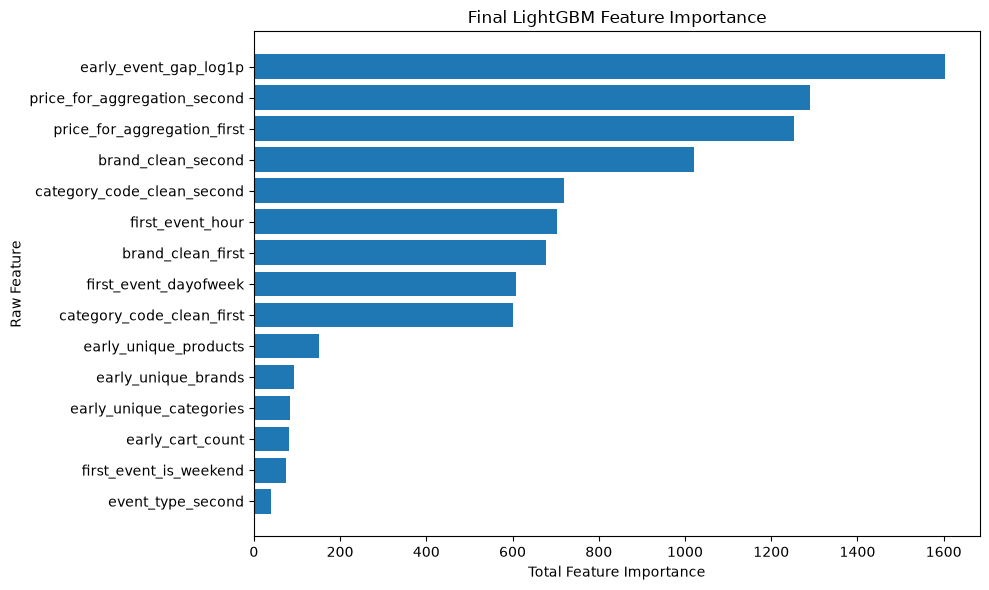

Saved feature importance chart:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\reports\step4_final_lightgbm_feature_importance.png


In [19]:
# Cell 17: Final LightGBM Feature Importance

import matplotlib.pyplot as plt


def map_transformed_feature_to_source(transformed_feature, raw_features):
    """Map transformed pipeline feature names back to their original raw feature."""
    clean_name = transformed_feature.split("__", maxsplit=1)[-1]

    if clean_name.startswith("missingindicator_"):
        clean_name = clean_name.replace("missingindicator_", "")

    for raw_feature in sorted(raw_features, key=len, reverse=True):
        if clean_name == raw_feature or clean_name.startswith(f"{raw_feature}_"):
            return raw_feature

    return "derived_or_imputation_indicator"


final_preprocessor = final_lightgbm_pipeline.named_steps["preprocessor"]
final_lightgbm_model = final_lightgbm_pipeline.named_steps["model"]

final_transformed_feature_names = final_preprocessor.get_feature_names_out()

final_transformed_feature_importance = pd.DataFrame({
    "transformed_feature": final_transformed_feature_names,
    "feature_importance": final_lightgbm_model.feature_importances_
})

final_transformed_feature_importance["source_feature"] = (
    final_transformed_feature_importance["transformed_feature"]
    .apply(
        lambda feature: map_transformed_feature_to_source(
            feature,
            retained_raw_features
        )
    )
)

final_transformed_feature_importance = (
    final_transformed_feature_importance
    .sort_values("feature_importance", ascending=False)
    .reset_index(drop=True)
)

final_raw_feature_importance = (
    final_transformed_feature_importance
    .groupby("source_feature", as_index=False)
    .agg(
        total_importance=("feature_importance", "sum"),
        transformed_components=("transformed_feature", "size")
    )
    .sort_values("total_importance", ascending=False)
    .reset_index(drop=True)
)

final_raw_feature_importance["importance_percentage"] = (
    final_raw_feature_importance["total_importance"]
    / final_raw_feature_importance["total_importance"].sum()
    * 100
)

print("Final LightGBM Raw Feature Importance")
display(final_raw_feature_importance)

print("Top Final LightGBM Transformed Feature Importance")
display(final_transformed_feature_importance.head(30))

top_features_for_chart = (
    final_raw_feature_importance
    .head(15)
    .sort_values("total_importance", ascending=True)
)

FINAL_FEATURE_IMPORTANCE_CHART_PATH = (
    REPORTS_FOLDER
    / "step4_final_lightgbm_feature_importance.png"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features_for_chart["source_feature"],
    top_features_for_chart["total_importance"]
)
plt.title("Final LightGBM Feature Importance")
plt.xlabel("Total Feature Importance")
plt.ylabel("Raw Feature")
plt.tight_layout()
plt.savefig(
    FINAL_FEATURE_IMPORTANCE_CHART_PATH,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved feature importance chart:")
print(FINAL_FEATURE_IMPORTANCE_CHART_PATH)

### Final LightGBM Feature Importance

The final LightGBM feature-importance analysis showed that the strongest predictors were early event timing, observed product prices, and product context.

The most important feature was `early_event_gap_log1p`, indicating that the time between the first two events was highly informative for predicting future purchase. The first and second observed product prices were also important, suggesting that early price exposure contributed predictive value.

Brand and category features from the first and second events also ranked highly. This supports the earlier EDA finding that early product context varies meaningfully across future-purchase outcomes.

Although `early_cart_count` showed strong signal in EDA and correlation analysis, its final LightGBM importance was lower. This does not invalidate its relationship with future purchase. In tree-based models, importance can be distributed across correlated or interacting features, especially when event type, category, brand, price, and timing are included together.

The final feature-importance chart was saved in the `reports/` folder for documentation and presentation use.

# Save Final Model, Metrics, Metadata, and Artifact Manifest

In [20]:
# Cell 18: Save Final LightGBM Model Artifacts

FINAL_LIGHTGBM_MODEL_PATH = (
    MODELS_FOLDER
    / "step4_final_lightgbm_purchase_propensity_pipeline.joblib"
)

FINAL_LIGHTGBM_METADATA_PATH = (
    MODELS_FOLDER
    / "step4_final_lightgbm_model_metadata.json"
)

FINAL_RAW_IMPORTANCE_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_raw_feature_importance.csv"
)

FINAL_TRANSFORMED_IMPORTANCE_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_transformed_feature_importance.csv"
)

FINAL_TEST_EVALUATION_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_test_evaluation_summary.csv"
)

FINAL_MODEL_COMPARISON_REPORT_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_model_comparison_report.csv"
)

FINAL_ARTIFACT_MANIFEST_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_model_artifact_manifest.csv"
)

# Save model pipeline.
joblib.dump(
    final_lightgbm_pipeline,
    FINAL_LIGHTGBM_MODEL_PATH
)

# Save evaluation and feature importance outputs.
final_test_summary.to_csv(
    FINAL_TEST_EVALUATION_PATH,
    index=False
)

final_raw_feature_importance.to_csv(
    FINAL_RAW_IMPORTANCE_PATH,
    index=False
)

final_transformed_feature_importance.to_csv(
    FINAL_TRANSFORMED_IMPORTANCE_PATH,
    index=False
)

# Build final model comparison report.
final_model_comparison_report = initial_validation_model_comparison.copy()
final_model_comparison_report["evaluation_period"] = "Validation"
final_model_comparison_report["selection_basis"] = "Initial model comparison"

final_test_report_row = final_test_summary.copy()
final_test_report_row["evaluation_period"] = "Untouched chronological test set"
final_test_report_row["selection_basis"] = "Final selected model evaluation"

final_model_comparison_report = pd.concat(
    [
        final_model_comparison_report,
        final_test_report_row
    ],
    ignore_index=True,
    sort=False
)

final_model_comparison_report.to_csv(
    FINAL_MODEL_COMPARISON_REPORT_PATH,
    index=False
)

# Save metadata for reproducibility.
final_model_metadata = {
    "model_name": FINAL_MODEL_NAME,
    "algorithm": "LightGBM LGBMClassifier",
    "target_variable": TARGET_COLUMN,
    "prediction_time": "After first two session events",
    "selected_probability_threshold": float(FINAL_THRESHOLD),
    "selection_metric": "Validation PR-AUC / Average Precision",
    "test_pr_auc": float(final_test_result["pr_auc"]),
    "test_roc_auc": float(final_test_result["roc_auc"]),
    "test_accuracy": float(final_test_result["accuracy"]),
    "test_precision": float(final_test_result["precision"]),
    "test_recall": float(final_test_result["recall"]),
    "test_f1_score": float(final_test_result["f1_score"]),
    "test_sessions_targeted": int(final_test_result["sessions_targeted"]),
    "test_percentage_targeted": float(final_test_result["percentage_targeted"]),
    "training_validation_sessions": int(len(X_train_validation)),
    "test_sessions": int(len(X_test)),
    "retained_raw_features": retained_raw_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "final_model_parameters": {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 1.0,
        "class_weight": "balanced",
        "objective": "binary",
        "random_state": RANDOM_STATE
    },
    "python_version": sys.version.split()[0],
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__
}

with open(FINAL_LIGHTGBM_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(final_model_metadata, file, indent=4)

artifact_manifest = pd.DataFrame({
    "artifact": [
        "Final LightGBM model pipeline",
        "Final LightGBM model metadata",
        "Final LightGBM test predictions",
        "Final LightGBM test evaluation summary",
        "Final LightGBM raw feature importance",
        "Final LightGBM transformed feature importance",
        "Final LightGBM feature importance chart",
        "Initial validation model comparison",
        "LightGBM tuning results",
        "Top-model threshold comparison",
        "Top-model ranking comparison",
        "Final model comparison report"
    ],
    "path": [
        str(FINAL_LIGHTGBM_MODEL_PATH),
        str(FINAL_LIGHTGBM_METADATA_PATH),
        str(FINAL_TEST_PREDICTIONS_PATH),
        str(FINAL_TEST_EVALUATION_PATH),
        str(FINAL_RAW_IMPORTANCE_PATH),
        str(FINAL_TRANSFORMED_IMPORTANCE_PATH),
        str(FINAL_FEATURE_IMPORTANCE_CHART_PATH),
        str(INITIAL_VALIDATION_COMPARISON_PATH),
        str(LIGHTGBM_TUNING_RESULTS_PATH),
        str(THRESHOLD_COMPARISON_PATH),
        str(RANKING_COMPARISON_PATH),
        str(FINAL_MODEL_COMPARISON_REPORT_PATH)
    ]
})

artifact_manifest.to_csv(
    FINAL_ARTIFACT_MANIFEST_PATH,
    index=False
)

print("Saved final Step 4 artifacts:")
display(artifact_manifest)

print("Artifact manifest:")
print(FINAL_ARTIFACT_MANIFEST_PATH)

Saved final Step 4 artifacts:


,artifact,path
0,Final LightGBM model pipeline,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
1,Final LightGBM model metadata,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
2,Final LightGBM test predictions,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
3,Final LightGBM test evaluation summary,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
4,Final LightGBM raw feature importance,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
5,Final LightGBM transformed feature importance,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
6,Final LightGBM feature importance chart,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
7,Initial validation model comparison,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
8,LightGBM tuning results,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
9,Top-model threshold comparison,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...


Artifact manifest:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_final_model_artifact_manifest.csv


# Step 4 Conclusion: Model Implementation

Step 4 implemented, compared, tuned, and evaluated supervised machine learning models for leakage-safe future-purchase prediction.

The model-ready dataset was loaded and split chronologically into training, validation, and test sets. The chronological split preserved the time order of sessions and prevented future-period data from influencing model training or validation.

Six supervised classification models were trained and compared: Logistic Regression, Decision Tree, Random Forest, Extra Trees, XGBoost, and LightGBM. These models provided a mix of linear baseline, single-tree baseline, bagging ensemble, randomized tree ensemble, and gradient boosting approaches.

PR-AUC was used as the primary model-selection metric because future-purchase sessions are the minority class. Based on initial validation results, LightGBM achieved the highest validation PR-AUC at 0.4877 and was selected as the provisional best model. XGBoost ranked second, while Random Forest produced strong threshold-based precision and F1-score.

LightGBM was tuned using TimeSeriesSplit cross-validation on the training set only. The tuned LightGBM improved some threshold-based validation metrics, such as precision and F1-score, but did not improve validation PR-AUC. Because PR-AUC was the primary selection metric, the original LightGBM configuration was retained as the final selected model.

Threshold analysis was then performed on the validation set. A threshold of 0.65 was selected because it provided a strong balance between precision, recall, F1-score, and targeted-session volume. At this threshold, LightGBM targeted around 10.81% of validation sessions with a precision of about 59.93%.

The final LightGBM model was retrained using the combined training and validation data, then evaluated once on the untouched chronological test set. On the test set, the model achieved a PR-AUC of 0.4824, ROC-AUC of 0.7802, precision of 61.38%, recall of 48.96%, and F1-score of 0.5447 at the selected threshold of 0.65. The model targeted 1,489 test sessions, equivalent to 10.70% of the test set, and correctly identified 914 future-purchase sessions.

Feature importance analysis showed that the strongest predictors were early event timing, first and second observed product prices, brand, category, and temporal features. The most important raw feature was `early_event_gap_log1p`, followed by `price_for_aggregation_second`, `price_for_aggregation_first`, `brand_clean_second`, and `category_code_clean_second`.

All required Step 4 artifacts were saved, including the trained model pipeline, model metadata, validation comparison reports, tuning results, threshold and ranking comparisons, final test predictions, final test evaluation summary, feature importance reports, and artifact manifest.

The Step 4 deliverable was completed successfully: trained models, evaluation metrics, model comparison, final selected model, and saved reproducible artifacts.

## Step 4 Deliverable Checklist

| Requirement | Status | Evidence |
|---|---|---|
| Train appropriate models | Completed | Logistic Regression, Decision Tree, Random Forest, Extra Trees, XGBoost, and LightGBM were trained. |
| Compare models fairly | Completed | All models used the same dataset, same chronological split, same preprocessing function, and same validation set. |
| Use relevant metrics | Completed | PR-AUC, ROC-AUC, accuracy, precision, recall, F1-score, sessions targeted, and targeting percentage were reported. |
| Tune best model | Completed | LightGBM was tuned using TimeSeriesSplit and average precision scoring. |
| Select final model | Completed | Initial LightGBM was selected based on highest validation PR-AUC and strong ranking performance. |
| Evaluate on untouched test set | Completed | Final LightGBM was evaluated once on the chronological test set. |
| Save reproducible artifacts | Completed | Model pipeline, metadata, predictions, metrics, feature importance, reports, and artifact manifest were saved. |